# Generating embeddings using TorchGeo

## 1. Dataset organization

### Downloading the CropHarvest dataset

In [68]:
from torchgeo.datasets import CropHarvest

RANDOM_STATE = 1998
ROOT = "_data"
OUTPUT_FOLDER = "_results/"
original_dataset = CropHarvest(root=ROOT, download=True)

In [ ]:
# pandas dataframe containing label data for everything on CropHarvest
original_dataset._load_labels(ROOT).head(5)

,type,properties.harvest_date,properties.planting_date,properties.label,properties.classification_label,properties.index,properties.is_crop,properties.lat,properties.lon,properties.dataset,properties.collection_date,properties.export_end_date,properties.externally_contributed_dataset,properties.is_test,geometry.type,geometry.coordinates,geometry
0,Feature,None,None,None,None,0,1,10.712596,37.083128,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0825205254332, 10.712735028397], [37.083...",NaN
1,Feature,None,None,None,None,1,1,10.724197,37.087377,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0872134731101, 10.7239755790256], [37.08...",NaN
2,Feature,None,None,None,None,2,1,10.713894,37.085091,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0849835772546, 10.7137105808623], [37.08...",NaN
3,Feature,None,None,None,None,3,1,10.713338,37.090290,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0902073888884, 10.7132048338664], [37.09...",NaN
4,Feature,None,None,None,None,4,1,10.721858,37.083121,ethiopia,2020-10-22T00:00:00,2021-02-01T00:00:00,False,False,Polygon,"[[[37.0830703114103, 10.7215953100434], [37.08...",NaN


### Exploring the dataset

In [3]:
# under properties.dataset we can find the names of the "sub datasets" inside CropHarvest
original_dataset_counts = original_dataset.labels['properties.dataset'].value_counts()

#  all the subdataset inside the CropHarvest dataset and the number of its samples
print("Sub-datasets inside CropHarvest:")
print(original_dataset_counts)

Sub-datasets inside CropHarvest:
properties.dataset
geowiki-landcover-2017          35866
croplands                       14976
canada                           9088
ile-de-france                    6184
central-asia                     5302
rwanda-ceo                       3600
reunion-france                   2776
kenya-non-crop                   2704
germany                          2550
martinique-france                2421
tanzania-ceo                     2400
mali-helmets-labelling-crops     1506
togo                             1276
lem-brazil                        860
ethiopia                          830
tanzania-rice-ecaas               800
sudan                             422
tanzania                          392
kenya                             319
togo-eval                         306
uganda                            233
mali                              148
mali-non-crop                     142
zimbabwe                           49
brazil-non-crop                    3

In [4]:
# group by the sub dataset name and look at the 'properties.label' column, which contains the crop type names
# if it is binary it will be None
# if it is multiclass it will have the crop type names

original_dataset_class_search = original_dataset.labels.groupby('properties.dataset')['properties.label'].unique()

binary = []
multiclass = []

for sub_dataset, labels in original_dataset_class_search.items():
    labels = [l for l in labels if l is not None and not (isinstance(l, float))]

    if len(labels) > 0:
        multiclass.append((sub_dataset, labels))
    else:
        binary.append(sub_dataset)

print("Binary sub-datasets:")
for i in binary:
    print(i)

print("\nMulticlass sub-datasets:")
for j in multiclass:
    print(j)

Binary sub-datasets:
brazil-non-crop
ethiopia
geowiki-landcover-2017
kenya-non-crop
mali-non-crop
rwanda-ceo
sudan
tanzania-ceo
togo
togo-eval

Multiclass sub-datasets:
('canada', ['wetland', 'abandoned (overgrown)', 'urban', 'shrubland', 'mixed forage', 'pasture (undiff)', 'sod', 'cereals (undiff)', 'barley (undiff)', 'corn', 'timothy', 'alfalfa', 'spring wheat', 'soybeans', 'forest', 'nursery', 'winter barley', 'canola/rapeseed', 'winter wheat', 'unimproved pasture', 'christmas trees', 'greenhouse', 'winter rye', 'pasture/forage', 'red clover', 'abandoned (shrubs)', 'other', 'fallow', 'native grassland', 'barren', 'water', 'oats', 'coniferous', 'white clover', 'broadleaf', 'clover (undiff)', 'sunflowers', 'greenfeed (mixed)', 'beans (undiff)', 'melon', 'apples', 'vegetables (undiff)', 'raspberry', 'fruits (berry & annual)', 'strawberry', 'onions', 'potatoes', 'broccoli', 'cauliflower', 'peas (undiff)', 'field peas', 'sugarbeets', 'ginseng', 'rye (undiff)', 'cherries', 'cucumber', 'to

### Isolate *geowiki-landcover-2017* sub dataset


We want to work with an isolated sub-set, binary, and preferably with lots of samples. For that reason it is wise to choose *geowiki-landcover-2017*
- **Sub dataset name:** *geowiki-landcover-2017*
- **Sample Count:** 35866 points
- **Format:** pixel-level time series

In [380]:
from torch.utils.data import Subset

# finding all the entries on original_dataset that has properties.dataset equal to 'geowiki-landcover-2017'
DATASET_NAME = 'kenya-non-crop'
geowiki_indices = original_dataset.labels.index[original_dataset.labels['properties.dataset'] == DATASET_NAME].tolist()

# create the isolated dataset
geowiki_dataset = Subset(original_dataset, geowiki_indices)

print(f"Original dataset size: {len(original_dataset)}")
print(f"Isolated dataset size: {len(geowiki_dataset)}")

Original dataset size: 70213
Isolated dataset size: 2704


In [381]:
def study(index, subset, original, geowiki_indices):
    label_my_dataset = subset.__getitem__(index)['label']
    idx_original = geowiki_indices[index]
    label_original_dataset = original[idx_original]['label']
    coordinates = original.labels['geometry.coordinates'][idx_original] 
    is_crop_cena = original.labels['properties.is_crop'][idx_original]
    print("label my dataset:", label_my_dataset)
    print("label original dataset:", label_original_dataset)
    print(f"coordinates: {coordinates[1], coordinates[0]}")
    print("verify if it says is_crop:", is_crop_cena)
    return None
study(0, geowiki_dataset, original_dataset, geowiki_indices)

label my dataset: tensor(12)
label original dataset: tensor(12)


IndexError: list index out of range

In [374]:
def study(rangee, subset, original, geowiki_indices):
    certo = []
    errado = []
    for i in range(rangee):
        label_my_dataset = subset.__getitem__(i)['label']
        idx_original = geowiki_indices[i]
        label_original_dataset = original[idx_original]['label']
        is_crop_cena = original.labels['properties.is_crop'][idx_original]

        if int(label_my_dataset) > 0:
            label_my_dataset_bianry = 1
            if label_my_dataset_bianry == is_crop_cena:
                certo.append(1)
            else: 
                errado.append(1)
        if int(label_my_dataset) == 0:
            if int(label_original_dataset) == is_crop_cena:
                certo.append(0)
            else:
                errado.append(0)
    return certo, errado

In [375]:
ver = study(14975, geowiki_dataset, original_dataset, geowiki_indices)

IndexError: list index out of range

In [360]:
certo = ver[0]
errado = ver[1]
print(f"correct matches: {len(certo)} and incorrect matches {len(errado)}")

correct matches: 12543 and incorrect matches 2432


In [382]:
def study_improved(subset, original, geowiki_indices, num_samples=25):
    certo = []
    errado = []

    print(f"{'Idx':<5} | {'My Tensor':<10} | {'Orig Tensor':<11} | {'Meta Crop':<10} | {'Status'}")
    print("-" * 60)

    for i in range(num_samples):
        # 1. Get labels from both objects
        label_my_dataset = int(subset[i]['label'])
        idx_original = geowiki_indices[i]
        label_original_dataset = int(original[idx_original]['label'])
        
        # 2. Get the raw metadata "is_crop" value
        is_crop_meta = int(original.labels['properties.is_crop'].iloc[idx_original])
        
        # 3. Apply your logic: if label > 0, it's a Crop (1)
        my_binary = 1 if label_my_dataset > 0 else 0
        
        # 4. Verify match with metadata
        if my_binary == is_crop_meta:
            status = "✅ MATCH"
            certo.append(i)
        else:
            status = "❌ MISMATCH"
            errado.append(i)

        # Print the row for visual inspection
        print(f"{i:<5} | {label_my_dataset:<10} | {label_original_dataset:<11} | {is_crop_meta:<10} | {status}")

    print("-" * 60)
    print(f"Total Matches: {len(certo)} | Total Mismatches: {len(errado)}")
    return certo, errado

# Run the study
certo, errado = study_improved(geowiki_dataset, original_dataset, geowiki_indices)

Idx   | My Tensor  | Orig Tensor | Meta Crop  | Status
------------------------------------------------------------
0     | 12         | 12          | 0          | ❌ MISMATCH
1     | 34         | 34          | 0          | ❌ MISMATCH
2     | 1          | 1           | 0          | ❌ MISMATCH
3     | 1          | 1           | 0          | ❌ MISMATCH
4     | 0          | 0           | 0          | ✅ MATCH
5     | 1          | 1           | 0          | ❌ MISMATCH
6     | 1          | 1           | 0          | ❌ MISMATCH
7     | 1          | 1           | 0          | ❌ MISMATCH
8     | 1          | 1           | 0          | ❌ MISMATCH
9     | 255        | 255         | 0          | ❌ MISMATCH
10    | 10         | 10          | 0          | ❌ MISMATCH
11    | 0          | 0           | 0          | ✅ MATCH
12    | 79         | 79          | 0          | ❌ MISMATCH
13    | 0          | 0           | 0          | ✅ MATCH
14    | 1          | 1           | 0          | ❌ MISMATCH
15    | 

### Turning *geowiki-landcover-2017* into a binary dataset

But we can see that, even though the sub dataset *geowiki-landcover-2017* is binary and has no `properties.label` associated with, there are many possible values for the label, meaning that has in fact is a multi classes.

For that reason we'll apply a transformation on the label tensor, making sure that all 0 label values remain 0 (non crop) and that any other value is turned into 1 (crop).

In [7]:
import torch

class BinaryDatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __getitem__(self, index):
        sample = self.subset[index]
        
        sample['label'] = torch.tensor(1) if sample['label'] > 0 else torch.tensor(0)
        return sample

    def __len__(self):
        return len(self.subset)

dataset = BinaryDatasetWrapper(geowiki_dataset)

In [8]:
print("Original geowiki dataset:")
print(geowiki_dataset[45]['label'])
print(geowiki_dataset[35865]['label'])
print(geowiki_dataset[0]['label'])

print("\nBinary geowiki dataset:")
print(dataset[45]['label'])
print(dataset[35865]['label'])
print(dataset[0]['label'])

Original geowiki dataset:
tensor(62)
tensor(74)
tensor(0)

Binary geowiki dataset:
tensor(1)
tensor(1)
tensor(0)


## 2. *geowiki-landcover-2017* data exploration

### Data structure

Each data point represents a single geographic location over a full calendar year. Each sample is provided as a $12 \times 18$ tensor:
- Rows (12): Represent the **12 monthsof the year (temporal dimension)
- Columns (18): Represent the spectral and environmental bands (feature dimension)

The data combines multiple sensors and environmental variables:

| Band Index | Feature Category | Description |
| :--- | :--- | :--- |
| **0 - 12** | **Sentinel-2 (Optical)** | Multi-spectral bands including RGB, NIR, and Red-Edge |
| **13 - 14** | **Sentinel-1 (Radar)** | VV and VH polarizations (crucial for cloud-penetrating growth monitoring) |
| **15** | **ERA5 (Temp)** | 2-meter temperature data (average monthly) |
| **16** | **ERA5 (Precip)** | Total monthly precipitation |
| **17** | **SRTM (Elevation)** | Digital Elevation Model (Static value repeated across time steps) |

In [361]:
original_dataset.all_bands

('VV',
 'VH',
 'B2',
 'B3',
 'B4',
 'B5',
 'B6',
 'B7',
 'B8',
 'B8A',
 'B9',
 'B11',
 'B12',
 'temperature_2m',
 'total_precipitation',
 'elevation',
 'slope',
 'NDVI')

In [362]:
dataset[7].keys()

dict_keys(['array', 'label'])

In [363]:
sample = dataset.__getitem__(2213) # close to a school
sample

{'array': tensor([[-9.5703e+00, -1.7248e+01,  1.2530e+03,  1.4400e+03,  1.5550e+03,
           1.6640e+03,  2.4710e+03,  2.9210e+03,  2.8720e+03,  3.3320e+03,
           6.9100e+02,  2.9140e+03,  1.6620e+03,  3.0036e+02,  4.9776e-04,
           1.2800e+02,  0.0000e+00,  3.3960e-01],
         [-8.4323e+00, -1.7839e+01,  1.1780e+03,  1.3450e+03,  1.3570e+03,
           1.3270e+03,  2.7120e+03,  3.4580e+03,  3.2830e+03,  3.9140e+03,
           5.5700e+02,  2.6580e+03,  1.3980e+03,  3.0046e+02,  1.0008e-03,
           1.2800e+02,  0.0000e+00,  4.3993e-01],
         [-1.2730e+01, -1.9005e+01,  2.5350e+03,  2.2990e+03,  2.1840e+03,
           2.2990e+03,  2.8150e+03,  3.1210e+03,  3.1090e+03,  3.2590e+03,
           5.0600e+02,  2.6040e+03,  1.7950e+03,  2.9973e+02,  6.6257e-04,
           1.2800e+02,  0.0000e+00,  1.5166e-01],
         [-1.1355e+01, -2.0069e+01,  1.6230e+03,  1.4820e+03,  1.4840e+03,
           1.4350e+03,  1.8470e+03,  2.2420e+03,  1.8800e+03,  2.5000e+03,
           3.400

In [364]:
sample['array'].shape # data itself

torch.Size([12, 18])

In [365]:
sample['label'].shape # binary label

torch.Size([])

### Data visualization

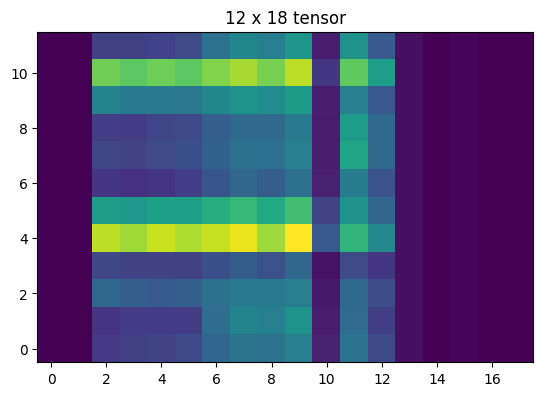

In [366]:
import matplotlib.pyplot as plt

# the actual tensor
plt.imshow(sample['array'], origin='lower')
plt.title("12 x 18 tensor")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.3616666666666667..2.341].


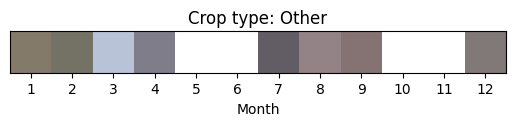

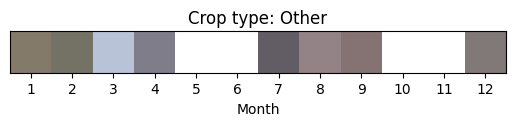

In [367]:
# it shows two plots because it is prepared to plot ground-truth and 
# it combines the rgb channels into a single pixel 
original_dataset.plot(sample)

In [16]:
# # load the crop-type label for a single pixel time series
# original_dataset._load_label(45, dataset='geowiki-landcover-2017')

# para ver depois porque é que isto acontece

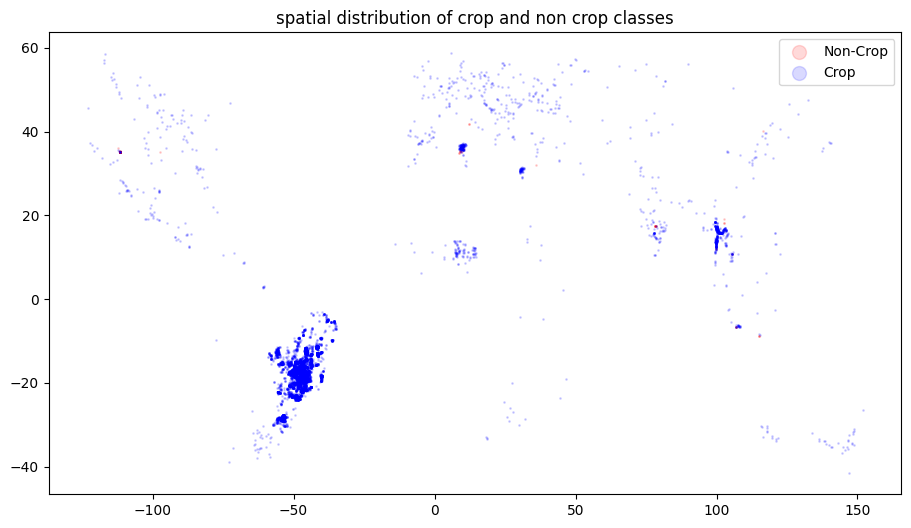

In [368]:
plt.figure(figsize=(11, 6))

geowiki_metadata = original_dataset.labels.iloc[geowiki_indices]

for is_crop, color, label in [(0, 'red', 'Non-Crop'), (1, 'blue', 'Crop')]:
    mask = geowiki_metadata['properties.is_crop'] == is_crop
    subset = geowiki_metadata[mask]
    plt.scatter(subset['properties.lon'], subset['properties.lat'], s=1, alpha=0.15, c=color, label=label)

plt.legend(markerscale=10)
plt.title("spatial distribution of crop and non crop classes")
plt.show()

## 3. Creating the embeddings model

### Extracting lat and long 

Because the metadata will be lost after the embeddings are generated, it is necessary to save, at least, the latitude and longitude, following the same index order that the *geowiki-landcover-2017* dataset has.

In [30]:
import pandas as pd
import numpy as np
from tqdm import tqdm

def get_dataset_coordinates(dataset):
    indices = dataset.subset.indices
    
    master_meta = dataset.subset.dataset.labels
    
    lats, lons, labels = [], [], []
    
    for i in tqdm(range(len(dataset)), desc="Recovering coordinates"):
        original_idx = indices[i]
        
        row = master_meta.iloc[original_idx]
        
        lats.append(row['properties.lat'])
        lons.append(row['properties.lon'])
        
        labels.append(dataset[i]['label'].item())
        
    df = pd.DataFrame({'lat': lats, 
                       'lon': lons, 
                       'label': labels})
    
    return df

df_coords = get_dataset_coordinates(dataset)

Recovering coordinates: 100%|██████████| 35866/35866 [06:24<00:00, 93.38it/s]


### DOFA model

Instead of trying to retrain the whole DOFA model (which is huge and requires a lot of GPU memory), we will use DOFA as a "frozen" backbone to generate embeddings and train a simple, fast classifier on top.

In [31]:
import lightning as L
from torch.utils.data import DataLoader

class GeoWikiDataModule(L.LightningDataModule):
    def __init__(self, data, batch_size: int = 32, num_workers: int = 0):
        super().__init__()
        self.data = data
        self.batch_size = batch_size
        self.num_workers = num_workers

    def dataloader(self):
        return DataLoader(
            self.data, 
            batch_size=self.batch_size, 
            shuffle=False, 
            num_workers=self.num_workers
        )

In [32]:
# loading data
data_module = GeoWikiDataModule(dataset, batch_size=16, num_workers=0)
data_loader = data_module.dataloader()

In [33]:
# define device to use, cuda, cpu or mps (our case with mac)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps") # for mac users
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [34]:
from torchgeo.models import DOFABase16_Weights, get_model

model = get_model('dofa_base_patch16_224', weights=DOFABase16_Weights.DOFA_MAE)
model = model.eval()

/Users/devseed/Documents/repos/embeddings_in_TorchGeo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [35]:
import torch.nn.functional as F
import numpy as np
from tqdm import tqdm

def embeddings_dofa(model, dataloader, device):
    model.eval()
    model.to(device)
    x_all, y_all = [] , []
    
    wavelengths = [60.0, 60.0, 490.0, 560.0, 665.0, 842.0, 1610.0, 2190.0, 
                   865.0, 705.0, 740.0, 783.0, 0.0, 0.0, 0.0, 0.0, 0.0, 490.0]

    for batch in tqdm(dataloader):
        x = batch['array'].to(torch.float32).to(device) 
        y = batch['label']

        # why doing this?!
        x = x.permute(0, 2, 1) 
        # and why doing this?!
        x = x.unsqueeze(-1)
        # also why doing this?!
        x = F.pad(x, (0, 15, 0, 4)) 

        with torch.inference_mode():
            features = model.forward_features(x, wavelengths=wavelengths)
            
            # why doing this?!
            if features.ndim == 3:
                # why doing this?!
                embeddings = features.mean(dim=1) 
            else:
                embeddings = features

        x_all.append(embeddings.cpu().numpy())
        y_all.append(y.numpy())

    return np.concatenate(x_all, axis=0), np.concatenate(y_all, axis=0)

In [179]:
# ensure that is running on mps or chosen device
model = model.to(device) 

print("Extracting embeddings...")
x, y = embeddings_dofa(model, data_loader, device)

print(f"Done! Created {x.shape[0]} vectors of size {x.shape[1]}")

Extracting embeddings...


100%|██████████| 2242/2242 [44:36<00:00,  1.19s/it]

Done! Created 35866 vectors of size 768


In [ ]:
# save the embeddings
np.save(f'{OUTPUT_FOLDER}x_dofa.npy', x)
np.save(f'{OUTPUT_FOLDER}y_dofa.npy', y)

print("Files saved successfully!")

### Sanity check

In [45]:
# load the embeddings
x = np.load(f'{OUTPUT_FOLDER}x_dofa.npy')
y = np.load(f'{OUTPUT_FOLDER}y_dofa.npy')

print("Files loaded successfully!")

Files loaded successfully!


In [125]:
# checking if the indexes match on dataset, extracted coordinates and embeddings' labels
for i in range(5):
    if dataset[i]['label'] == df_coords['label'][i] == y[i]:
        print(f"Label for index {i} matches on all sets! For index {i}, label = {dataset[i]['label']} and coordinates = {float(df_coords['lat'][i]), float(df_coords['lon'][i])}!")
    else:
        print(f"Label for index {i} doesn't match on all sets")

Label for index 0 matches on all sets! For index 0, label = 0 and coordinates = (-16.54761905, 46.25)!
Label for index 1 matches on all sets! For index 1, label = 1 and coordinates = (-18.54761905, 48.25)!
Label for index 2 matches on all sets! For index 2, label = 0 and coordinates = (-21.54761905, 44.25)!
Label for index 3 matches on all sets! For index 3, label = 1 and coordinates = (-17.54761905, 45.25)!
Label for index 4 matches on all sets! For index 4, label = 1 and coordinates = (-21.54761905, 46.25)!


In [127]:
df_coords['lat'][0], df_coords['lon'][0]

(np.float64(-16.54761905), np.float64(46.25))

In [128]:
dataset.subset.indices[0]

3694

In [131]:
original_idx = dataset.subset.indices[0]

meta_row = dataset.subset.dataset.labels.iloc[original_idx]

lat = meta_row['properties.lat']
lon = meta_row['properties.lon']
label = dataset[0]['label']

print(f"Sample corresponds to Original Row: {original_idx}")
print(f"Coordinates: Lat {lat}, Lon {lon}")
print(f"Label: {label}")

Sample corresponds to Original Row: 3694
Coordinates: Lat -16.54761905, Lon 46.25
Label: 0


## Analysing the results

### Train/test split

In [143]:
split_ratio = int(len(dataset)*0.8)

x_train = x[:split_ratio]
y_train = y[:split_ratio]
coords_train = df_coords[:split_ratio]

x_test = x[split_ratio:]
y_test = y[split_ratio:]
coords_test = df_coords[split_ratio:]

In [154]:
def get_class_balance(data_input):
    if isinstance(data_input, (np.ndarray, list)):
        total = len(data_input)
        unique, counts_arr = np.unique(data_input, return_counts=True)
        counts = dict(zip(unique, counts_arr))
        
    else:
        if not hasattr(data_input, 'indices'):
            indices = range(len(data_input))
        else:
            indices = data_input.indices

        curr = data_input
        while not hasattr(curr, 'labels'):
            if hasattr(curr, 'dataset'):
                curr = curr.dataset
            elif hasattr(curr, 'subset'):
                curr = curr.subset
            else:
                break
        
        if hasattr(curr, 'labels'):
            labels_series = curr.labels.iloc[indices]['properties.is_crop']
            counts = labels_series.value_counts().to_dict()
            total = len(indices)
        else:
            print("Error: Could not find labels in the dataset hierarchy.")
            return None

    crop_count = counts.get(1, 0)
    non_crop_count = counts.get(0, 0)
    
    print(f"Total Samples: {total}")
    print(f"  - Crop (1):     {crop_count} ({100*crop_count/total:.1f}%)")
    print(f"  - Non-Crop (0): {non_crop_count} ({100*non_crop_count/total:.1f}%)")
        
    return counts

In [162]:
int(dataset[0]['label']) == 1

False

In [163]:
crop = []
non_crop = []
for i in range(len(dataset)):
    if int(dataset[i]['label']) == 0:
        non_crop.append(i)
    else:
        crop.append(i)

In [175]:
tudo = len(crop)+len(non_crop)
e_crop = (len(crop)/tudo)*100
nao_e_ecrop = (len(non_crop)/tudo)*100
print(tudo)
print("crop:", e_crop)
print("non crop:", nao_e_ecrop)

35866
crop: 67.0384207884905
non crop: 32.96157921150951


In [168]:
crop_test= []
non_crop_test = []
for j in range(len(y_test)):
    if int(y_test[j]) == 0:
        non_crop_test.append(j)
    else:
        crop_test.append(j)

In [174]:
tudo_test = len(crop_test)+len(non_crop_test)
e_crop_test = (len(crop_test)/tudo_test)*100
nao_e_ecrop_test = (len(non_crop_test)/tudo_test)*100
print(tudo_test)
print("crop:", e_crop_test)
print("non crop:", nao_e_ecrop_test)

7174
crop: 74.61667131307499
non crop: 25.383328686925005


In [155]:
get_class_balance(dataset)

Total Samples: 35866
  - Crop (1):     18604 (51.9%)
  - Non-Crop (0): 17262 (48.1%)


{1: 18604, 0: 17262}

In [156]:
get_class_balance(y_train)

Total Samples: 28692
  - Crop (1):     18691 (65.1%)
  - Non-Crop (0): 10001 (34.9%)


{np.int64(0): np.int64(10001), np.int64(1): np.int64(18691)}

In [176]:
get_class_balance(y_test)

Total Samples: 7174
  - Crop (1):     5353 (74.6%)
  - Non-Crop (0): 1821 (25.4%)


{np.int64(0): np.int64(1821), np.int64(1): np.int64(5353)}

### Simple classifier

In [ ]:
# Check if the label from the dataset matches the label in our y_train
sample_idx = 100
dataset_label = train_dataset[sample_idx]['label']
extracted_label = y_train[sample_idx]

print(f"Dataset Label: {dataset_label}, Extracted Label: {extracted_label}")
# If these match, your coordinates are perfectly aligned!

Dataset Label: 1, Extracted Label: 1


In [29]:
import numpy as np

x_train = np.load('_results/x_train_dofa.npy')
y_train = np.load('_results/y_train_dofa.npy')

x_test = np.load('_results/x_test_dofa.npy')
y_test = np.load('_results/y_test_dofa.npy')

In [30]:
# # verify with dummy logistic regression

# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import cross_val_score

# clf = LogisticRegression(max_iter=2000)
# scores = cross_val_score(clf, x_train, y_train, cv=5)

# print(scores.mean())

In [ ]:
# verify with random forest

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# training
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(x_train, y_train)

# predicting
y_pred = rf.predict(x_test)

# evaluating
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.801
              precision    recall  f1-score   support

           0       0.75      0.59      0.66      2354
           1       0.82      0.90      0.86      4820

    accuracy                           0.80      7174
   macro avg       0.78      0.75      0.76      7174
weighted avg       0.80      0.80      0.79      7174



In [32]:
# seeing the training embeddings
x_train

array([[-0.6843597 ,  1.3317857 , -0.1730215 , ..., -1.0050291 ,
         1.4445201 ,  0.16924465],
       [-0.7558303 ,  1.3373078 , -0.12454218, ..., -0.938168  ,
         1.5349168 ,  0.27727735],
       [-0.6637167 ,  1.2818854 , -0.00314577, ..., -1.0425191 ,
         1.4366606 ,  0.49263978],
       ...,
       [-0.6163079 ,  0.46319622, -0.065437  , ..., -0.88993376,
         1.6282924 ,  0.20553823],
       [-0.73618203,  0.5652616 , -0.11604235, ..., -1.0232474 ,
         1.1033449 ,  0.39190474],
       [-0.9262897 ,  0.5352571 , -0.07066359, ..., -1.1458124 ,
         0.8557055 ,  0.52568597]], shape=(28692, 768), dtype=float32)

### Embeddings visualization

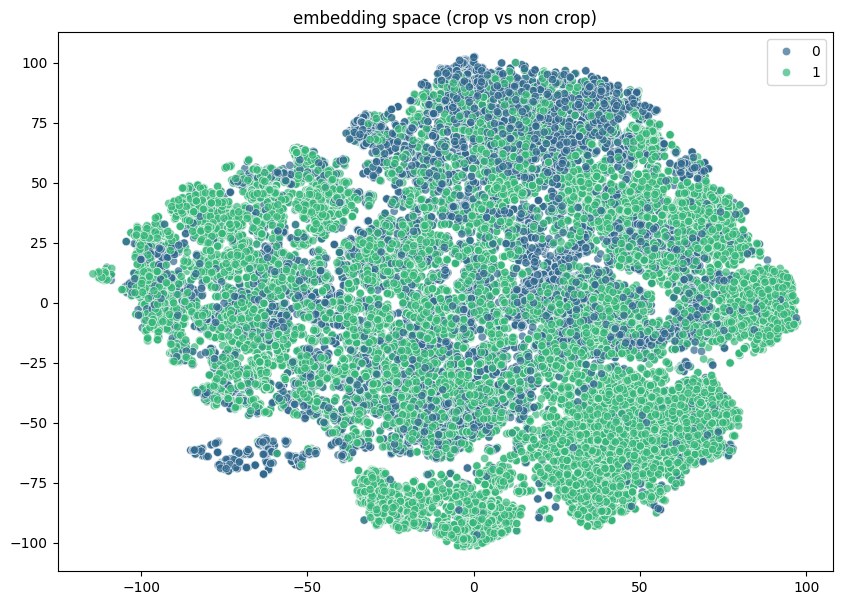

In [ ]:
from sklearn.manifold import TSNE
import seaborn as sns

tsne = TSNE(n_components=2, random_state=RANDOM_STATE)
x_2d = tsne.fit_transform(x)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=x_2d[:,0], y=x_2d[:,1], hue=y, palette='viridis', alpha=0.7)
plt.title("embedding space (crop vs non crop)")
plt.show()

### Spatial correlation of the embeddings

In [37]:
# Check if the label from the dataset matches the label in our y_train
sample_idx = 100
dataset_label = train_dataset[sample_idx]['label']
extracted_label = y_train[sample_idx]

print(f"Dataset Label: {dataset_label}, Extracted Label: {extracted_label}")
# If these match, your coordinates are perfectly aligned!

Dataset Label: 1, Extracted Label: 1


In [65]:
import re

def get_coordinates_from_files(train_or_test_subset):
    # 1. Drill down to the original TorchGeo CropHarvest object
    wrapper = train_or_test_subset.dataset
    inner_subset = wrapper.subset
    original_ds = inner_subset.dataset
    
    # 2. Get the list of file paths
    all_files = original_ds.files
    
    # 3. Get the mapping of indices
    outer_indices = train_or_test_subset.indices
    inner_indices = inner_subset.indices
    
    lats, lons = [], []
    
    # Regex to find numbers after 'lat' and 'lon' in the file string
    # This works for formats like "lat_0.5_lon_10.2" or "0.5_10.2"
    for outer_idx in tqdm(outer_indices, desc="Parsing Filenames"):
        actual_original_idx = inner_indices[outer_idx]
        file_path = all_files[actual_original_idx]
        
        # We search for the pattern of the coordinate in the string
        # Most CropHarvest file structures use: .../index_lat_lon/
        try:
            # Look for numbers (including negatives and decimals)
            parts = re.findall(r"[-+]?\d*\.\d+|\d+", file_path)
            # Usually the last two or specific indices are lat/lon
            # Adjusting to standard CropHarvest folder naming:
            lats.append(float(parts[-2]))
            lons.append(float(parts[-1]))
        except:
            # If regex fails, we print one path to see the format
            if outer_idx == outer_indices[0]:
                print(f"DEBUG: File path format is: {file_path}")
            lats.append(0.0)
            lons.append(0.0)
            
    return np.column_stack((lats, lons))

# Run the parser
coords_train = get_coordinates_from_files(train_dataset)
coords_test = get_coordinates_from_files(test_dataset)

Parsing Filenames: 100%|██████████| 28692/28692 [00:00<00:00, 579020.16it/s]


DEBUG: File path format is: {'chip': '_data/features/arrays/22189_geowiki-landcover-2017.h5', 'index': '22189', 'dataset': 'geowiki-landcover-2017'}


Parsing Filenames: 100%|██████████| 7174/7174 [00:00<00:00, 715388.05it/s]

DEBUG: File path format is: {'chip': '_data/features/arrays/28956_geowiki-landcover-2017.h5', 'index': '28956', 'dataset': 'geowiki-landcover-2017'}


In [66]:
coords_test

array([[0., 0.],
       [0., 0.],
       [0., 0.],
       ...,
       [0., 0.],
       [0., 0.],
       [0., 0.]], shape=(7174, 2))